In [ ]:
from function_lib import *

In [ ]:
# ----------------- config -----------------
n_instance   = 100
input_dim    = 3
noise        = 0.5
deg          = 2
grid_width   = 3
n_simulation = 30
epoch        = 5000
learning_rate = 0.1

# ----------------- paths ------------------
base_path = change_to_py_file_dir()
base      = os.path.join(base_path, "Data", "Shortest_path")

ckpt_root = Path(base_path) / "Result" / "Train" / "ckpt_dir"
log_dir  = Path(base_path) / "Result" / "Train" / "CSVlogger"
ckpt_root.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)

# ----------------- graph / solver ---------
G      = define_graph(grid_width)
solver = ShortestPathSolver(G)

# ----------------- results ----------------
total_result  = {}
# =========================================================
# main loop over seeds
# =========================================================
for model_type in ["mse", "spo"]:
    regret_result = []
    ModelClass   = get_model_class(model_type)
    for seed in range(n_simulation):
        # ---- reproducibility ----
        pl.seed_everything(seed, workers=True)
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        # ---- data ----
        y_train, x_test, y_test, train_dl, valid_dl, test_dl = load_shortest_path_setting_with_splits(base, n_instance, input_dim, deg, noise, grid_width, seed, batch_size=32)

        # optional: pre-compute solpool if you actually use it somewhere
        # otherwise you can safely delete these two lines
        # y_train_t = torch.from_numpy(y_train).float()
        # solpool   = batch_solve(solver, y_train_t, relaxation=False)

        ckpt_dir = ckpt_root / f"{model_type}_seed_{seed}"

        # clean checkpoint directory for this seed
        shutil.rmtree(ckpt_dir, ignore_errors=True)
        ckpt_dir.mkdir(parents=True, exist_ok=True)
        log_dir.mkdir(parents=True, exist_ok=True)

        # ---- network (new net for each seed!) ----
        net = nn.Linear(input_dim, 2 * grid_width * (grid_width - 1))

        # ---- callbacks (recreated each seed) ----
        checkpoint_callback = ModelCheckpoint(
            monitor="val_regret",                 # must match your logged metric name
            dirpath=str(ckpt_dir),
            filename="model-{epoch:02d}-{val_regret:.4f}",
            mode="min",
            save_top_k=1
        )

        early_stop_callback = EarlyStopping(
            monitor="val_regret",
            mode="min",
            patience=100,
            min_delta=0.0,
            verbose=False
        )

        # ---- logger ----
        tb_logger = create_csv_logger(
            log_dir=str(log_dir),
            experiment_name=model_type,
            seed=seed
        )

        # ---- model ----
        model = ModelClass(
            net=net,
            solver=solver,
            lr=learning_rate,
            max_epochs=epoch
        )

        # ---- trainer ----
        trainer = pl.Trainer(
            max_epochs=epoch,
            min_epochs=5,
            accelerator="auto",            # "auto" is safer; uses GPU if available
            devices=1,
            callbacks=[checkpoint_callback, early_stop_callback],
            logger=tb_logger,
            enable_progress_bar=False,
            deterministic=True
        )

        # optional sanity check: initial validation
        trainer.validate(model, dataloaders=valid_dl)

        # ---- training ----
        trainer.fit(model, train_dataloaders=train_dl, val_dataloaders=valid_dl)

        # ---- load best model and test ----
        best_model_path = checkpoint_callback.best_model_path
        if not best_model_path:
            raise RuntimeError(
                f"No checkpoint saved for seed {seed}. "
                "Check that 'val_regret' is logged in validation_step/validation_epoch_end."
            )

        best_model = ModelClass.load_from_checkpoint(
            checkpoint_path=best_model_path,
            net=nn.Linear(input_dim, 2 * grid_width * (grid_width - 1)),  # fresh net with same shape
            solver=solver,
            lr=learning_rate,
            max_epochs=epoch
        )

        test_result = trainer.test(best_model, dataloaders=test_dl)
        regret_result.append(test_result[0]["test_regret"])

    total_result[model_type] = regret_result
    print(f"{model_type} regrets over {n_simulation} seeds:", regret_result)

Seed set to 22
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | net       | Linear  | 48     | train
1 | criterion | MSELoss | 0      | train
----------------------------------------------
48        Trainable params
0         Non-trainable params
48        Total params
0.000     Total estimated model params size (MB)
2         Modules in train mode
0         Modules in eval mode


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_mse             74.08792877197266
       test_regret          0.0658220574259758
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
[INFO] Removing existing logger folder: c:\Users\zhaoz\Desktop\Project\Robust-learning-to-rank\SGD\Result\Train\CSVlogger\spo\version_22
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         val_mse            115.28675842285156
       val_regret           0

Seed set to 23
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | net       | Linear  | 48     | train
1 | criterion | MSELoss | 0      | train
----------------------------------------------
48        Trainable params
0         Non-trainable params
48        Total params
0.000     Total estimated model params size (MB)
2         Modules in train mode
0         Modules in eval mode


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_mse            158.97813415527344
       test_regret          0.1606985628604889
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
[INFO] Removing existing logger folder: c:\Users\zhaoz\Desktop\Project\Robust-learning-to-rank\SGD\Result\Train\CSVlogger\spo\version_23
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         val_mse            169.09226989746094
       val_regret           0

Seed set to 24
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | net       | Linear  | 48     | train
1 | criterion | MSELoss | 0      | train
----------------------------------------------
48        Trainable params
0         Non-trainable params
48        Total params
0.000     Total estimated model params size (MB)
2         Modules in train mode
0         Modules in eval mode


...

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_mse            120.57582092285156
       test_regret          0.09060917049646378
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
[INFO] Removing existing logger folder: c:\Users\zhaoz\Desktop\Project\Robust-learning-to-rank\SGD\Result\Train\CSVlogger\spo\version_27
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         val_mse            127.19847106933594
       val_regret           

Seed set to 28
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | net       | Linear  | 48     | train
1 | criterion | MSELoss | 0      | train
----------------------------------------------
48        Trainable params
0         Non-trainable params
48        Total params
0.000     Total estimated model params size (MB)
2         Modules in train mode
0         Modules in eval mode


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_mse             119.799072265625
       test_regret         0.043850384652614594
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
[INFO] Removing existing logger folder: c:\Users\zhaoz\Desktop\Project\Robust-learning-to-rank\SGD\Result\Train\CSVlogger\spo\version_28
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         val_mse             177.261474609375
       val_regret           0.

Seed set to 29
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | net       | Linear  | 48     | train
1 | criterion | MSELoss | 0      | train
----------------------------------------------
48        Trainable params
0         Non-trainable params
48        Total params
0.000     Total estimated model params size (MB)
2         Modules in train mode
0         Modules in eval mode


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_mse             146.8867645263672
       test_regret          0.1967771053314209
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
[INFO] Removing existing logger folder: c:\Users\zhaoz\Desktop\Project\Robust-learning-to-rank\SGD\Result\Train\CSVlogger\spo\version_29
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         val_mse             189.4526824951172
       val_regret           0

In [3]:

def compute_stats(arr):
    arr = np.asarray(arr)

    # mean
    mean = np.mean(arr)

    # sample standard deviation (ddof=1)
    std = np.std(arr, ddof=1)

    # VaR 90 (90th percentile)
    var90 = np.percentile(arr, 90)

    # CVaR 90 = mean of tail losses exceeding VaR90
    tail = arr[arr >= var90]
    cvar90 = tail.mean() if len(tail) > 0 else var90

    return mean, std, var90, cvar90


# Example usage:

mean, std, var90, cvar90 = compute_stats(total_result['spo'])

print(f"Mean    : {mean:.6f}")
print(f"Std     : {std:.6f}")
print(f"VaR 90  : {var90:.6f}")
print(f"CVaR 90 : {cvar90:.6f}")

mean, std, var90, cvar90 = compute_stats(total_result['mse'])

print(f"Mean    : {mean:.6f}")
print(f"Std     : {std:.6f}")
print(f"VaR 90  : {var90:.6f}")
print(f"CVaR 90 : {cvar90:.6f}")

Mean    : 0.103746
Std     : 0.055835
VaR 90  : 0.190491
CVaR 90 : 0.203534
Mean    : 0.135482
Std     : 0.063339
VaR 90  : 0.215815
CVaR 90 : 0.257748


C:\Users\zhaoz\AppData\Local\Temp\ipykernel_21860\4188343004.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


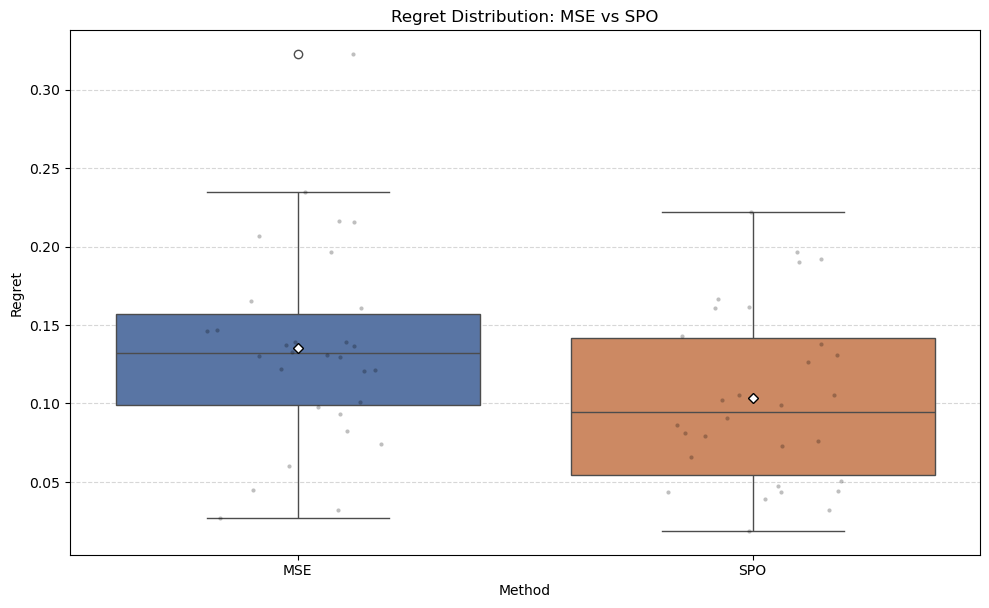

In [4]:


# Prepare data for seaborn
df = pd.DataFrame({
    "regret": total_result["mse"] + total_result["spo"],
    "method": ["MSE"] * len(total_result["mse"]) + ["SPO"] * len(total_result["spo"])
})

# Academic color palette
palette = sns.color_palette("deep")  # high-contrast, journal-friendly
method_colors = {"MSE": palette[0], "SPO": palette[1]}

plt.figure(figsize=figure_size(10))  # Width of 6 inches, height based on golden ratio

sns.boxplot(
    data=df,
    x="method",
    y="regret",
    palette=method_colors,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 5
    }
)

sns.stripplot(
    data=df,
    x="method",
    y="regret",
    color="black",
    alpha=0.25,
    jitter=0.2,
    size=3
)

plt.title("Regret Distribution: MSE vs SPO", fontsize=12)
plt.ylabel("Regret")
plt.xlabel("Method")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(base_path + "\\Result\\Figures\\baseline_result_demo.png", dpi=400, bbox_inches='tight')  # Save figure
plt.show()


In [5]:
# save path
save_path = os.path.join(base_path, "Result", "Score", f"spo_regret_sp_{n_instance}_{input_dim}_{noise}_{grid_width}.pkl")

with open(save_path, "wb") as f:
    pickle.dump(total_result['spo'], f)

save_path = os.path.join(base_path, "Result", "Score", f"mse_regret_sp_{n_instance}_{input_dim}_{noise}_{grid_width}.pkl")

with open(save_path, "wb") as f:
    pickle.dump(total_result['mse'], f)

print(f"Saved stats to: {save_path}")

Saved stats to: c:\Users\zhaoz\Desktop\Project\Robust-learning-to-rank\SGD\Result\Score\mse_regret_sp_100_3_0.5_3.pkl


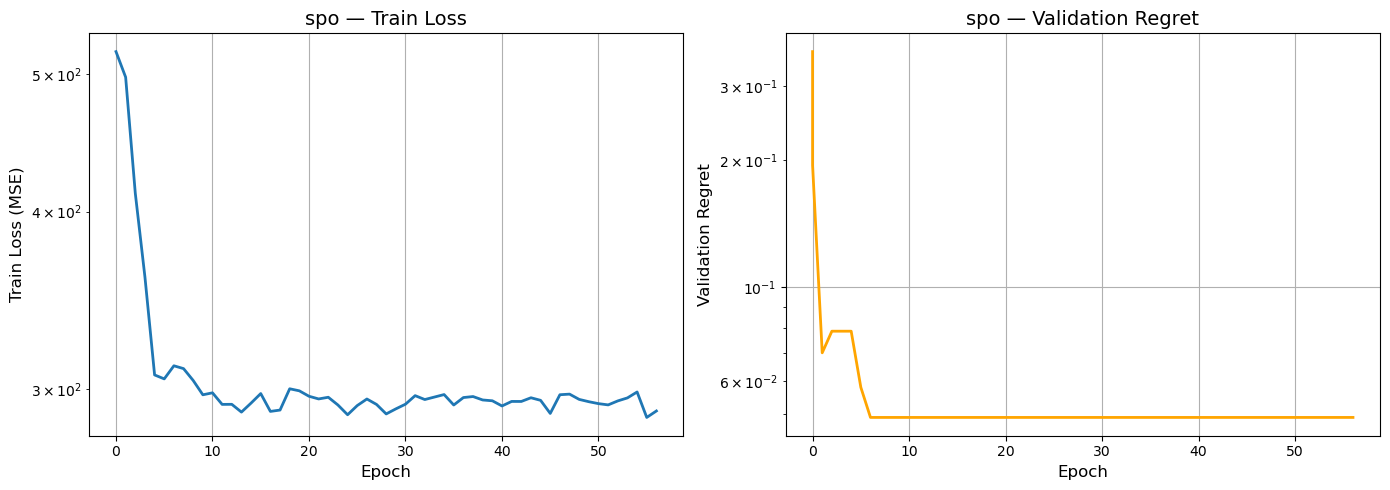

In [6]:
log_dir = base_path + '/Result/Train/CSVlogger'
plot_training_curves(log_dir, experiment_name=model_type, version=seed)

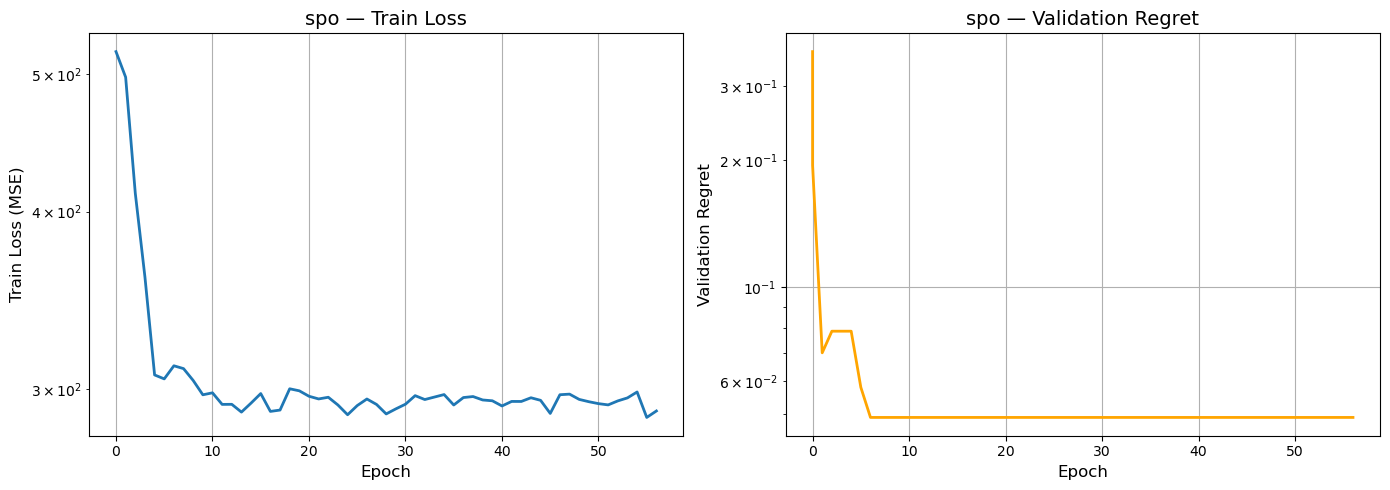

In [7]:

log_dir = base_path + '/Result/Train/CSVlogger'
plot_training_curves(log_dir, experiment_name=model_type, version=seed)